# 🤖 Nifty 50 — Feature Engineering & Model Training

**Input:** `nifty50_data/nifty50_cleaned.csv` (158,768 rows × 50 cols)  
**Output:** Trained model + predictions + evaluation report

### Steps:
1. Load cleaned data
2. Feature engineering (new features + encoding)
3. Feature selection
4. Train/test split (time-aware)
5. Train models (Random Forest, XGBoost, LightGBM)
6. Evaluate & compare models
7. Feature importance
8. Save best model + predictions

In [1]:
# Install required libraries if needed
!pip install xgboost lightgbm scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost not installed — skipping')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('⚠️  LightGBM not installed — skipping')

pd.set_option('display.float_format', '{:.4f}'.format)
os.makedirs('nifty50_model', exist_ok=True)
print('✅ Libraries loaded')

✅ Libraries loaded


---
## Step 1 — Load Cleaned Data

In [3]:
df = pd.read_csv('nifty50_data/nifty50_cleaned.csv', parse_dates=['date'])
df = df.sort_values(['Ticker', 'date']).reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Stocks     : {df["Ticker"].nunique()}')
print(f'Date range : {df["date"].min().date()} → {df["date"].max().date()}')
df.head(3)

Shape      : (158768, 50)
Stocks     : 48
Date range : 2012-02-01 → 2026-02-16


,date,close,high,low,open,volume,Ticker,MA_20,MA_50,MA_200,...,profit_margin,operating_margin,debt_to_equity,current_ratio,roe,roa,book_value,price_to_book,dividend_yield,beta
0,2012-02-01,133.3033,136.8698,131.6822,135.7582,899183,ADANIPORTS.NS,128.8035,121.0930,134.7315,...,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320
1,2012-02-02,139.8805,140.6216,133.8591,133.8591,2355597,ADANIPORTS.NS,130.1074,121.4385,134.7564,...,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320
2,2012-02-03,139.1857,141.4553,137.3330,139.8805,814359,ADANIPORTS.NS,131.1982,121.9332,134.7724,...,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320


---
## Step 2 — Feature Engineering

In [4]:
# ── 2a. Date-based features ───────────────────────────────────────────────
df['month']        = df['date'].dt.month
df['quarter']      = df['date'].dt.quarter
df['day_of_week']  = df['date'].dt.dayofweek   # 0=Mon, 4=Fri
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)

print('✅ Date features added')

✅ Date features added


In [5]:
# ── 2b. Price-based ratio features ───────────────────────────────────────
# Distance of price from moving averages (normalized)
df['price_vs_MA50']  = (df['close'] - df['MA_50'])  / df['MA_50']
df['price_vs_MA200'] = (df['close'] - df['MA_200']) / df['MA_200']
df['price_vs_MA20']  = (df['close'] - df['MA_20'])  / df['MA_20']

# MA crossover signals
df['MA50_vs_MA200']  = (df['MA_50'] - df['MA_200']) / df['MA_200']   # golden/death cross
df['MA20_vs_MA50']   = (df['MA_20'] - df['MA_50'])  / df['MA_50']

# 52-week high/low position (where is price in its range?)
df['price_range_52w'] = df.groupby('Ticker', group_keys=False).apply(
    lambda g: (g['close'] - g['close'].rolling(252).min()) /
              (g['close'].rolling(252).max() - g['close'].rolling(252).min() + 1e-9)
)

print('✅ Price ratio features added')

✅ Price ratio features added


In [6]:
# ── 2c. Momentum features ─────────────────────────────────────────────────
df['momentum_3m']  = df.groupby('Ticker')['close'].pct_change(63)   # ~3 months
df['momentum_6m']  = df.groupby('Ticker')['close'].pct_change(126)  # ~6 months
df['momentum_12m'] = df.groupby('Ticker')['close'].pct_change(252)  # ~12 months

# Relative strength vs Nifty50 index
df['rel_strength_1m'] = df['return_20d'] - df['Nifty50_return'].rolling(20).mean()

print('✅ Momentum features added')

✅ Momentum features added


In [7]:
# ── 2d. Volatility features ───────────────────────────────────────────────
df['volatility_20d'] = df.groupby('Ticker')['return_1d'].transform(
    lambda x: x.rolling(20).std()
)
df['volatility_60d'] = df.groupby('Ticker')['return_1d'].transform(
    lambda x: x.rolling(60).std()
)
# Volatility ratio — is current volatility higher than usual?
df['vol_regime'] = df['volatility_20d'] / (df['volatility_60d'] + 1e-9)

print('✅ Volatility features added')

✅ Volatility features added


In [8]:
# ── 2e. Macro ratio features ──────────────────────────────────────────────
# USD/INR momentum (rising INR = bad for import-heavy stocks)
df['usdinr_change_1m'] = df['USD_INR'].pct_change(20)

# Crude oil momentum (important for India)
df['oil_change_1m'] = df['Crude_oil_price'].pct_change(20)

# Gold momentum
df['gold_change_1m'] = df['Gold_price'].pct_change(20)

# Market trend — is Nifty50 above its 50-day MA?
df['market_trend'] = (df['Nifty50_close'] > df['Nifty50_MA50']).astype(int)

print('✅ Macro ratio features added')

✅ Macro ratio features added


In [9]:
# ── 2f. Encode Ticker as numeric ──────────────────────────────────────────
le = LabelEncoder()
df['ticker_encoded'] = le.fit_transform(df['Ticker'])

# Save encoder for later use in prediction
joblib.dump(le, 'nifty50_model/ticker_encoder.pkl')
print(f'✅ Ticker encoded ({df["Ticker"].nunique()} unique stocks)')

✅ Ticker encoded (48 unique stocks)


In [10]:
# Drop rows with NaNs introduced by new rolling features
before = len(df)
df = df.dropna().reset_index(drop=True)
after  = len(df)
print(f'✅ Dropped {before - after:,} rows with NaNs from new features')
print(f'   Remaining rows: {after:,}')
print(f'   Total columns : {df.shape[1]}')

✅ Dropped 12,096 rows with NaNs from new features
   Remaining rows: 146,672
   Total columns : 73


---
## Step 3 — Define Features & Target

In [11]:
# Columns to exclude from features
EXCLUDE = [
    'date', 'Ticker',           # identifiers
    'target_return_30d',        # target — never feed into model!
    'open', 'high', 'low',      # raw OHLC — already captured in technicals
    'close',                    # raw price — use normalized versions instead
    'volume',                   # raw volume — use vol_ratio instead
]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
TARGET_COL   = 'target_return_30d'

print(f'✅ Feature columns : {len(FEATURE_COLS)}')
print(f'✅ Target column   : {TARGET_COL}')
print(f'\nFeatures:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

✅ Feature columns : 65
✅ Target column   : target_return_30d

Features:
   1. MA_20
   2. MA_50
   3. MA_200
   4. EMA_20
   5. RSI_14
   6. MACD
   7. MACD_sig
   8. MACD_diff
   9. BB_upper
  10. BB_lower
  11. BB_width
  12. BB_pct
  13. return_1d
  14. return_5d
  15. return_10d
  16. return_20d
  17. vol_MA_20
  18. vol_ratio
  19. ATR_14
  20. USD_INR
  21. Nifty50_close
  22. Nifty50_return
  23. Nifty50_MA50
  24. India_10yr_yield
  25. Gold_price
  26. Crude_oil_price
  27. PE_ratio
  28. forward_PE
  29. EPS_trailing
  30. EPS_forward
  31. revenue_growth
  32. earnings_growth
  33. profit_margin
  34. operating_margin
  35. debt_to_equity
  36. current_ratio
  37. roe
  38. roa
  39. book_value
  40. price_to_book
  41. dividend_yield
  42. beta
  43. month
  44. quarter
  45. day_of_week
  46. is_month_end
  47. is_quarter_end
  48. price_vs_MA50
  49. price_vs_MA200
  50. price_vs_MA20
  51. MA50_vs_MA200
  52. MA20_vs_MA50
  53. price_range_52w
  54. momentum_3m
  55. mom

---
## Step 4 — Time-Aware Train / Test Split

> ⚠️ **Critical:** Never use random split for time-series!  
> If you randomly split, future data leaks into training → model looks great but fails in real use.  
> We always split by **date** — train on past, test on future.

In [12]:
# 80% train / 20% test — split by date
split_date = df['date'].quantile(0.80)
# Ensure split_date is a proper Timestamp
if not isinstance(split_date, pd.Timestamp):
    split_date = pd.Timestamp(split_date)

train_df = df[df['date'] <= split_date]
test_df  = df[df['date'] >  split_date]

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f'Split date   : {split_date.date()}')
print(f'Train rows   : {len(X_train):,}  ({len(X_train)/len(df)*100:.1f}%)')
print(f'Test rows    : {len(X_test):,}   ({len(X_test)/len(df)*100:.1f}%)')
print(f'Train period : {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Test period  : {test_df["date"].min().date()}  → {test_df["date"].max().date()}')

Split date   : 2023-08-16
Train rows   : 117,382  (80.0%)
Test rows    : 29,290   (20.0%)
Train period : 2013-02-08 → 2023-08-16
Test period  : 2023-08-17  → 2026-02-16


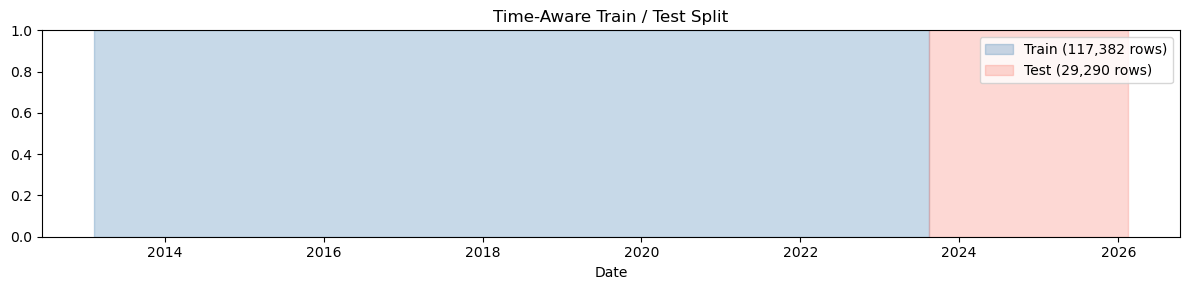

In [13]:
# Visualize the train/test split
fig, ax = plt.subplots(figsize=(12, 3))
ax.axvspan(train_df['date'].min(), train_df['date'].max(), alpha=0.3, color='steelblue', label=f'Train ({len(X_train):,} rows)')
ax.axvspan(test_df['date'].min(),  test_df['date'].max(),  alpha=0.3, color='salmon',    label=f'Test ({len(X_test):,} rows)')
ax.set_title('Time-Aware Train / Test Split')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Scale features — important for some models
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for inference
joblib.dump(scaler, 'nifty50_model/feature_scaler.pkl')
print('✅ Features scaled and scaler saved')

✅ Features scaled and scaler saved


---
## Step 5 — Train Models

In [15]:
# Helper: evaluate a trained model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    X_train_in = X_tr
    X_test_in  = X_te

    train_pred = model.predict(X_train_in)
    test_pred  = model.predict(X_test_in)

    # Direction accuracy — did we get UP/DOWN right?
    train_dir = (np.sign(train_pred) == np.sign(y_tr.values)).mean()
    test_dir  = (np.sign(test_pred)  == np.sign(y_te.values)).mean()

    results = {
        'Model'          : name,
        'Train RMSE'     : np.sqrt(mean_squared_error(y_tr, train_pred)),
        'Test RMSE'      : np.sqrt(mean_squared_error(y_te, test_pred)),
        'Train MAE'      : mean_absolute_error(y_tr, train_pred),
        'Test MAE'       : mean_absolute_error(y_te, test_pred),
        'Train R²'       : r2_score(y_tr, train_pred),
        'Test R²'        : r2_score(y_te, test_pred),
        'Train Dir Acc'  : train_dir,
        'Test Dir Acc'   : test_dir,
    }
    return results, test_pred

all_results = []
all_predictions = {}
print('✅ Evaluation helper ready')

✅ Evaluation helper ready


In [16]:
# ── Model 1: Random Forest ────────────────────────────────────────────────
print('🌲 Training Random Forest...')
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
res_rf, pred_rf = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)
all_results.append(res_rf)
all_predictions['Random Forest'] = pred_rf
joblib.dump(rf, 'nifty50_model/random_forest.pkl')
print(f'   Test RMSE: {res_rf["Test RMSE"]:.4f} | Test R²: {res_rf["Test R²"]:.4f} | Dir Acc: {res_rf["Test Dir Acc"]:.2%}')

🌲 Training Random Forest...
   Test RMSE: 0.0796 | Test R²: -0.0000 | Dir Acc: 58.41%


In [17]:
# ── Model 2: XGBoost ──────────────────────────────────────────────────────
if XGB_AVAILABLE:
    print('⚡ Training XGBoost...')
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    res_xgb, pred_xgb = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)
    all_results.append(res_xgb)
    all_predictions['XGBoost'] = pred_xgb
    joblib.dump(xgb_model, 'nifty50_model/xgboost.pkl')
    print(f'   Test RMSE: {res_xgb["Test RMSE"]:.4f} | Test R²: {res_xgb["Test R²"]:.4f} | Dir Acc: {res_xgb["Test Dir Acc"]:.2%}')
else:
    print('⚠️  XGBoost skipped')

⚡ Training XGBoost...
   Test RMSE: 0.0840 | Test R²: -0.1143 | Dir Acc: 57.35%


In [18]:
# ── Model 3: LightGBM ─────────────────────────────────────────────────────
if LGB_AVAILABLE:
    print('💡 Training LightGBM...')
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)])
    res_lgb, pred_lgb = evaluate_model('LightGBM', lgb_model, X_train, y_train, X_test, y_test)
    all_results.append(res_lgb)
    all_predictions['LightGBM'] = pred_lgb
    joblib.dump(lgb_model, 'nifty50_model/lightgbm.pkl')
    print(f'   Test RMSE: {res_lgb["Test RMSE"]:.4f} | Test R²: {res_lgb["Test R²"]:.4f} | Dir Acc: {res_lgb["Test Dir Acc"]:.2%}')
else:
    print('⚠️  LightGBM skipped')

💡 Training LightGBM...
   Test RMSE: 0.0827 | Test R²: -0.0801 | Dir Acc: 58.69%


---
## Step 6 — Evaluate & Compare Models

In [19]:
# Results comparison table
results_df = pd.DataFrame(all_results).set_index('Model')
print('=' * 70)
print('  MODEL COMPARISON')
print('=' * 70)
print(results_df.round(4).to_string())
print('=' * 70)

best_model_name = results_df['Test Dir Acc'].idxmax()
print(f'\n🏆 Best model by Directional Accuracy: {best_model_name}')
print(f'   Test Directional Accuracy: {results_df.loc[best_model_name, "Test Dir Acc"]:.2%}')
print(f'   Test RMSE                : {results_df.loc[best_model_name, "Test RMSE"]:.4f}')
print(f'   Test R²                  : {results_df.loc[best_model_name, "Test R²"]:.4f}')

  MODEL COMPARISON
               Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²  Train Dir Acc  Test Dir Acc
Model                                                                                                    
Random Forest      0.0689     0.0796     0.0546    0.0623    0.4281  -0.0000         0.7433        0.5841
XGBoost            0.0572     0.0840     0.0451    0.0659    0.6050  -0.1143         0.7998        0.5735
LightGBM           0.0626     0.0827     0.0495    0.0650    0.5283  -0.0801         0.7742        0.5869

🏆 Best model by Directional Accuracy: LightGBM
   Test Directional Accuracy: 58.69%
   Test RMSE                : 0.0827
   Test R²                  : -0.0801


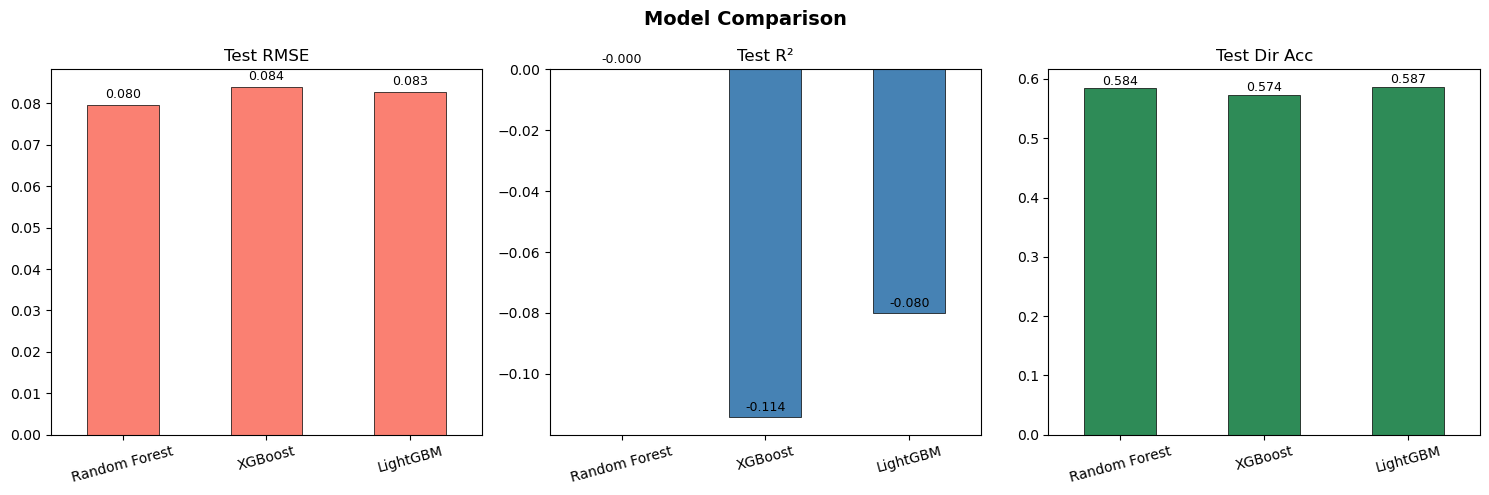

In [20]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Test RMSE', 'Test R²', 'Test Dir Acc']
colors  = ['salmon', 'steelblue', 'seagreen']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].plot(kind='bar', ax=ax, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(metric)
    ax.set_xticklabels(results_df.index, rotation=15)
    ax.set_xlabel('')
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

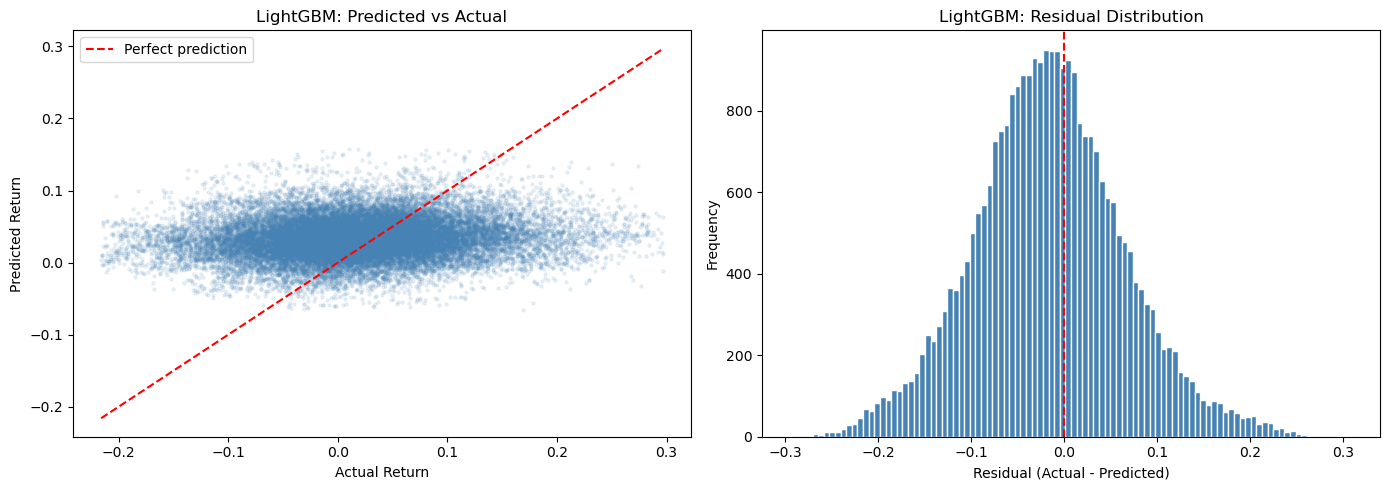

In [21]:
# Plot predicted vs actual for best model
best_preds = all_predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test, best_preds, alpha=0.1, s=5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Return')
axes[0].set_ylabel('Predicted Return')
axes[0].set_title(f'{best_model_name}: Predicted vs Actual')
axes[0].legend()

# Residuals distribution
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model_name}: Residual Distribution')

plt.tight_layout()
plt.show()

---
## Step 7 — Feature Importance

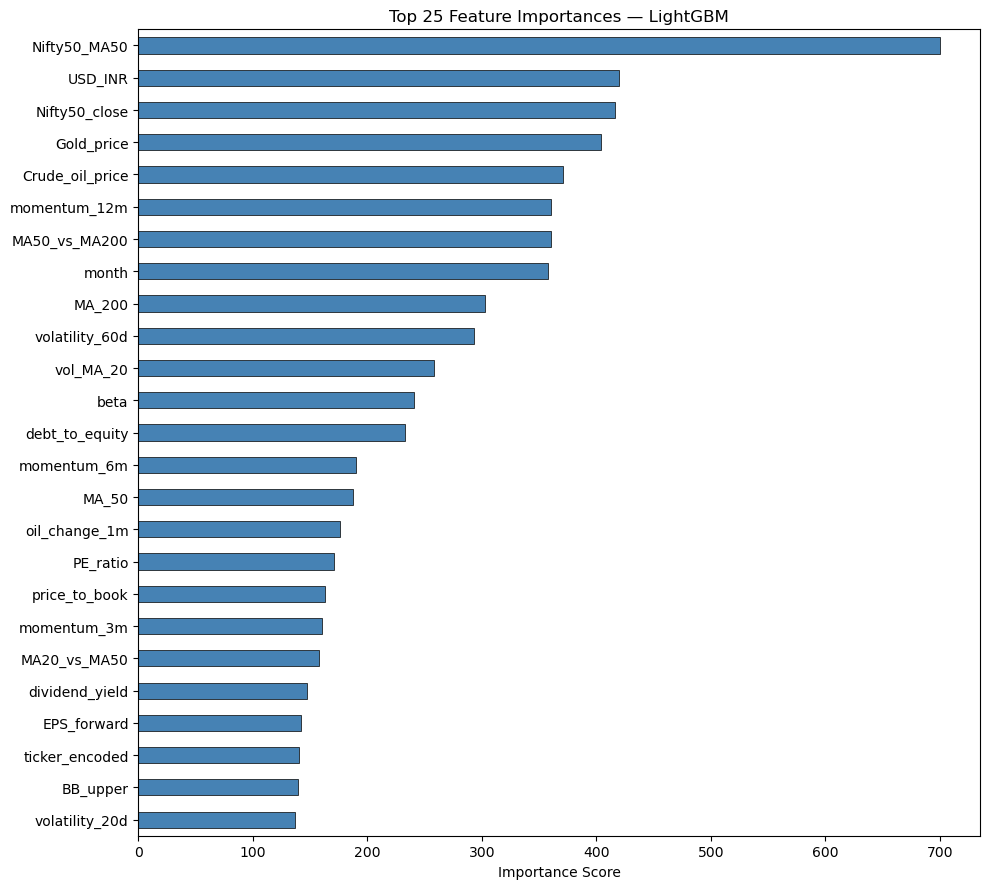

Top 25 features:
Nifty50_MA50       700
USD_INR            420
Nifty50_close      416
Gold_price         404
Crude_oil_price    371
momentum_12m       360
MA50_vs_MA200      360
month              358
MA_200             303
volatility_60d     293
vol_MA_20          258
beta               241
debt_to_equity     233
momentum_6m        190
MA_50              187
oil_change_1m      176
PE_ratio           171
price_to_book      163
momentum_3m        160
MA20_vs_MA50       158
dividend_yield     147
EPS_forward        142
ticker_encoded     140
BB_upper           139
volatility_20d     137


In [22]:
# Feature importance from best model
best_model_obj = {
    'Random Forest' : rf,
    'XGBoost'       : xgb_model if XGB_AVAILABLE else None,
    'LightGBM'      : lgb_model if LGB_AVAILABLE else None
}.get(best_model_name, rf)

importances = pd.Series(
    best_model_obj.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

# Plot top 25
fig, ax = plt.subplots(figsize=(10, 9))
importances.head(25).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5
)
ax.set_title(f'Top 25 Feature Importances — {best_model_name}')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 25 features:')
print(importances.head(25).round(4).to_string())

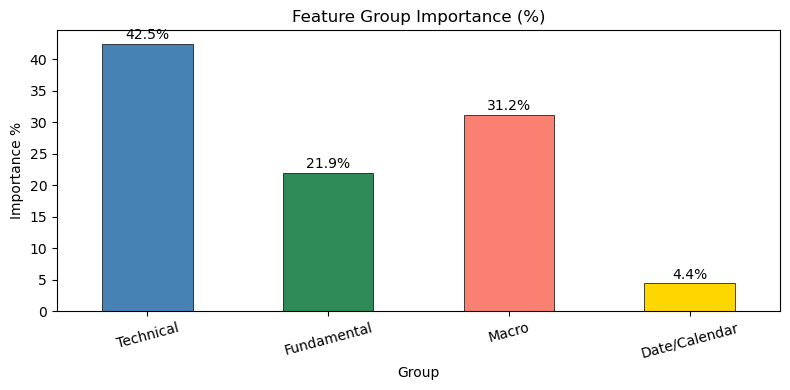

               Total Importance  Percentage
Group                                      
Technical                  3767     42.5000
Fundamental                1944     21.9000
Macro                      2760     31.2000
Date/Calendar               389      4.4000


In [23]:
# Group importance by feature category
technical_feats    = ['MA_20','MA_50','MA_200','EMA_20','RSI_14','MACD','MACD_sig','MACD_diff',
                      'BB_upper','BB_lower','BB_width','BB_pct','return_1d','return_5d',
                      'return_10d','return_20d','vol_MA_20','vol_ratio','ATR_14',
                      'price_vs_MA50','price_vs_MA200','price_vs_MA20','MA50_vs_MA200',
                      'MA20_vs_MA50','price_range_52w','momentum_3m','momentum_6m',
                      'momentum_12m','rel_strength_1m','volatility_20d','volatility_60d','vol_regime']
fundamental_feats  = ['PE_ratio','forward_PE','EPS_trailing','EPS_forward','revenue_growth',
                      'earnings_growth','profit_margin','operating_margin','debt_to_equity',
                      'current_ratio','roe','roa','book_value','price_to_book',
                      'dividend_yield','beta']
macro_feats        = ['USD_INR','Nifty50_close','Nifty50_return','Nifty50_MA50','Gold_price',
                      'Crude_oil_price','India_10yr_yield','usdinr_change_1m','oil_change_1m',
                      'gold_change_1m','market_trend']
date_feats         = ['month','quarter','day_of_week','is_month_end','is_quarter_end']

def group_importance(feats, label):
    cols = [f for f in feats if f in importances.index]
    return label, importances[cols].sum()

groups = [
    group_importance(technical_feats,   'Technical'),
    group_importance(fundamental_feats, 'Fundamental'),
    group_importance(macro_feats,       'Macro'),
    group_importance(date_feats,        'Date/Calendar'),
]

group_df = pd.DataFrame(groups, columns=['Group', 'Total Importance']).set_index('Group')
group_df['Percentage'] = (group_df['Total Importance'] / group_df['Total Importance'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
group_df['Percentage'].plot(kind='bar', ax=ax, color=['steelblue','seagreen','salmon','gold'],
                            edgecolor='black', linewidth=0.5)
ax.set_title('Feature Group Importance (%)')
ax.set_ylabel('Importance %')
ax.set_xticklabels(group_df.index, rotation=15)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()
print(group_df.to_string())

---
## Step 8 — Save Best Model & Predictions

In [24]:
# Save best model
joblib.dump(best_model_obj, 'nifty50_model/best_model.pkl')
joblib.dump(FEATURE_COLS,   'nifty50_model/feature_cols.pkl')

# Save test predictions with metadata
test_output = test_df[['date', 'Ticker', 'close']].copy()
test_output['actual_return_30d']    = y_test.values
test_output['predicted_return_30d'] = best_preds
test_output['error']                = y_test.values - best_preds
test_output['direction_correct']    = (np.sign(best_preds) == np.sign(y_test.values)).astype(int)
test_output['predicted_price_30d']  = test_output['close'] * (1 + test_output['predicted_return_30d'])

test_output.to_csv('nifty50_model/test_predictions.csv', index=False)

# Save results summary
results_df.to_csv('nifty50_model/model_results.csv')

print('✅ Saved:')
print('   nifty50_model/best_model.pkl')
print('   nifty50_model/feature_cols.pkl')
print('   nifty50_model/feature_scaler.pkl')
print('   nifty50_model/ticker_encoder.pkl')
print('   nifty50_model/test_predictions.csv')
print('   nifty50_model/model_results.csv')

✅ Saved:
   nifty50_model/best_model.pkl
   nifty50_model/feature_cols.pkl
   nifty50_model/feature_scaler.pkl
   nifty50_model/ticker_encoder.pkl
   nifty50_model/test_predictions.csv
   nifty50_model/model_results.csv


In [25]:
# Per-stock prediction accuracy
per_stock = test_output.groupby('Ticker').agg(
    Avg_Actual    = ('actual_return_30d',    'mean'),
    Avg_Predicted = ('predicted_return_30d', 'mean'),
    Dir_Accuracy  = ('direction_correct',    'mean'),
    MAE           = ('error', lambda x: x.abs().mean())
).round(4).sort_values('Dir_Accuracy', ascending=False)

print('Per-stock prediction accuracy (test set):')
print(per_stock.to_string())

Per-stock prediction accuracy (test set):
               Avg_Actual  Avg_Predicted  Dir_Accuracy    MAE
Ticker                                                       
EICHERMOT.NS       0.0421         0.0241        0.7411 0.0521
BHARTIARTL.NS      0.0393         0.0306        0.7236 0.0526
HDFCBANK.NS        0.0074         0.0158        0.7138 0.0463
HINDALCO.NS        0.0376         0.0098        0.6916 0.0736
SBIN.NS            0.0381         0.0299        0.6678 0.0588
JSWSTEEL.NS        0.0222         0.0265        0.6667 0.0448
BRITANNIA.NS       0.0173         0.0279        0.6667 0.0493
SBILIFE.NS         0.0225         0.0171        0.6570 0.0578
GRASIM.NS          0.0208         0.0420        0.6537 0.0499
COALINDIA.NS       0.0364         0.0637        0.6460 0.0867
M&M.NS             0.0328         0.0393        0.6383 0.0663
TATASTEEL.NS       0.0283         0.0452        0.6359 0.0719
APOLLOHOSP.NS      0.0231         0.0341        0.6343 0.0526
LT.NS              0.0187   

In [26]:
# Final summary
print('=' * 55)
print('  🏁 TRAINING COMPLETE')
print('=' * 55)
print(f'  Best model        : {best_model_name}')
print(f'  Test RMSE         : {results_df.loc[best_model_name, "Test RMSE"]:.4f}')
print(f'  Test R²           : {results_df.loc[best_model_name, "Test R²"]:.4f}')
print(f'  Directional Acc   : {results_df.loc[best_model_name, "Test Dir Acc"]:.2%}')
print(f'  Features used     : {len(FEATURE_COLS)}')
print(f'  Training samples  : {len(X_train):,}')
print(f'  Test samples      : {len(X_test):,}')
print('=' * 55)
print('\n🚀 Ready for Step 4: Live Prediction!')

  🏁 TRAINING COMPLETE
  Best model        : LightGBM
  Test RMSE         : 0.0827
  Test R²           : -0.0801
  Directional Acc   : 58.69%
  Features used     : 65
  Training samples  : 117,382
  Test samples      : 29,290

🚀 Ready for Step 4: Live Prediction!
